# Allen NWB Session to CSV Converter (Using neurocurator)

This notebook downloads a specific session from the Allen Institute NWB dataset using a session ID and converts it into a set of CSV files using the Neurocurator (neurocurator) processing pipeline.

The notebook:
- Downloads Allen Institute electrophysiology data by session ID
- Uses the existing `neurocurator.py` functions for data processing
- Exports data in the same CSV format as Neurocurator

## Usage Instructions

This notebook provides a streamlined workflow to:

### 1. **Session-based Download**
- Set `SESSION_ID` in the configuration cell to specify exactly which Allen Institute session to download
- Browse available sessions by setting `SESSION_ID = None`

### 2. **Neurocurator Processing** 
- Uses the existing `neurocurator.py` functions for all data processing
- Maintains compatibility with the Neurocurator pipeline
- Computes the same features as the original Neurocurator workflow

### 3. **Standardized CSV Export**
- **`waveforms.csv`**: Mean waveforms (50 time points per unit)
- **`metadata.csv`**: Comprehensive unit metadata with computed Neurocurator features
- **`isi_dist.csv`**: Interspike interval histograms (100ms bins)
- **`acg.csv`**: Autocorrelograms (200ms window)
- **`spike_times/`**: Individual CSV files per unit
- **`session_summary.txt`**: Complete session documentation

### 4. **Neurocurator Features Included**
- Waveform features (peak, trough, FWHM)
- Firing rates and minimum ISI
- ISI distributions and autocorrelograms 
- Position coordinates (CCF-based)
- All Allen Institute quality metrics

### 5. **Quick Start**
1. **Set session ID**: Modify `SESSION_ID = 715093703` to your desired session
2. **Run all cells**: Execute the notebook from top to bottom
3. **Check output**: Find CSV files in `./allen_session_[ID]_neurocurator_csv/`

### 6. **Customization Options**
- **Different session**: Change `SESSION_ID` and re-run
- **Browse sessions**: Set `SESSION_ID = None` to see available options
- **Additional features**: Add custom Neurocurator processing steps before export
- **Output format**: Modify CSV export section for different file structures

The processed data is fully compatible with downstream Neurocurator analysis pipelines and maintains the same format and feature set as the original Neurocurator processor.

In [10]:
# Import required libraries
import os
import sys
import numpy as np
import pandas as pd
from pathlib import Path
from allensdk.brain_observatory.ecephys.ecephys_project_cache import EcephysProjectCache
from pynwb import NWBHDF5IO
import matplotlib.pyplot as plt
from scipy import interpolate, signal
#from joblib import Parallel, delayed
import warnings
warnings.filterwarnings('ignore')

# Import the neurocurator module
sys.path.append('.')  # Add current directory to path
from neurocurator import Neurocurator

## Configuration and Session Selection

**Specify the session ID you want to download and process:**

In [4]:
# Configuration: Set your desired session ID here
SESSION_ID = 754312389  # Example session ID - change this to your desired session

# You can also set it to None to browse available sessions
# SESSION_ID = None

print(f"Target session ID: {SESSION_ID}")

# Setup Allen data cache with error handling
cache_dir = './allen_cache'
os.makedirs(cache_dir, exist_ok=True)
manifest_path = os.path.join(cache_dir, "manifest.json")

try:
    # Try to initialize cache
    cache = EcephysProjectCache.from_warehouse(manifest=manifest_path)
    print("Allen Institute data cache initialized successfully")
except Exception as e:
    print(f"Error initializing Allen cache: {e}")
    print("\nTrying alternative initialization...")
    
    # Clear cache and try again
    import shutil
    if os.path.exists(cache_dir):
        shutil.rmtree(cache_dir)
    os.makedirs(cache_dir, exist_ok=True)
    
    try:
        cache = EcephysProjectCache.from_warehouse(manifest=manifest_path)
        print("Allen Institute data cache initialized on second attempt")
    except Exception as e2:
        print(f"Still having issues: {e2}")
        print("\nTroubleshooting tips:")
        print("1. Update allensdk: pip install --upgrade allensdk")
        print("2. Check pandas compatibility: pip install 'pandas>=1.3.0,<2.0.0'")
        print("3. Clear cache directory manually and restart kernel")
        print("4. Try: pip install --upgrade numpy scipy matplotlib")
        cache = None

Target session ID: 754312389
Allen Institute data cache initialized successfully


In [5]:
# Session validation and optional browsing
if cache is not None:
    try:
        sessions = cache.get_session_table()
        print(f"Total available sessions: {len(sessions)}")
        
        if SESSION_ID is None:
            print("\nNo session ID specified. Showing available sessions:")
            print("Available session types:")
            print(sessions.session_type.value_counts())
            
            # Show some example sessions
            print("\nExample sessions (first 10):")
            display(sessions[['session_type', 'specimen_id', 'age_in_days', 'sex']].head(10))
            
            print("\nPlease set SESSION_ID in the configuration cell above and re-run.")
            session_id = None
            session_info = None
            
        elif SESSION_ID in sessions.index:
            session_id = SESSION_ID
            session_info = sessions.loc[session_id]
            print(f"\nSession {session_id} found!")
            print(f"Session type: {session_info.session_type}")
            print(f"Specimen ID: {session_info.specimen_id}")
            print(f"Brain regions: {session_info.ecephys_structure_acronyms}")
            print(f"Age: {session_info.age_in_days} days")
            print(f"Sex: {session_info.sex}")
            print(f"Genotype: {session_info.full_genotype}")
        else:
            print(f"\nSession {SESSION_ID} not found in available sessions.")
            print("Please check the session ID or browse available sessions by setting SESSION_ID = None")
            session_id = None
            session_info = None
            
    except Exception as e:
        print(f"Error accessing session table: {e}")
        sessions = None
        session_id = None
        session_info = None
else:
    print("Cannot access sessions - cache initialization failed.")
    sessions = None
    session_id = None
    session_info = None

Total available sessions: 58

Session 754312389 found!
Session type: brain_observatory_1.1
Specimen ID: 719828690
Brain regions: ['APN' 'POL' 'LP' 'DG' 'CA1' 'VISam' nan 'LGd' 'HPF' 'CA3' 'VISpm' 'VISp'
 'CA2' 'VISl' 'grey' 'TH' 'VISal' 'VISrl']
Age: 140.0 days
Sex: M
Genotype: wt/wt


## Download Session Data

In [7]:
# Download session data
if session_id is not None and cache is not None:
    print(f"Downloading session {session_id}... This may take a few minutes.")
    
    try:
        # Get session data with permissive quality filters
        session = cache.get_session_data(
            session_id,
            isi_violations_maximum=np.inf,
            amplitude_cutoff_maximum=np.inf,
            presence_ratio_minimum=-np.inf
        )
        
        print(f"Session downloaded successfully!")
        print(f"Number of units: {len(session.units)}")
        print(f"Session duration: {session.get_stimulus_epochs().duration.sum():.1f} seconds")
        
        # Display units information
        print("\nUnits overview:")
        display(session.units.head())
        
    except Exception as e:
        print(f"Error downloading session: {e}")
        session = None
        
else:
    print("Cannot download session - session_id or cache not available.")
    session = None

Session downloaded successfully!
Number of units: 1192
Session duration: 9127.8 seconds

Units overview:


,waveform_PT_ratio,waveform_amplitude,amplitude_cutoff,cluster_id,cumulative_drift,d_prime,firing_rate,isi_violations,isolation_distance,L_ratio,...,ecephys_structure_id,ecephys_structure_acronym,anterior_posterior_ccf_coordinate,dorsal_ventral_ccf_coordinate,left_right_ccf_coordinate,probe_description,location,probe_sampling_rate,probe_lfp_sampling_rate,probe_has_lfp_data
unit_id,,,,,,,,,,,,,,,,,,,,,
951801738,0.761831,81.013530,0.411609,1,387.65,2.960354,2.961611,0.128081,42.142917,0.026587,...,215.0,APN,8307.0,3130.0,7461.0,probeA,See electrode locations,29999.969397,1249.998725,True
951801727,0.601806,61.941945,0.500000,0,466.65,4.128437,3.367173,0.259704,57.848698,0.017635,...,215.0,APN,8307.0,3130.0,7461.0,probeA,See electrode locations,29999.969397,1249.998725,True
951801788,0.531259,70.163535,0.500000,5,341.33,3.615741,3.884460,0.174578,61.351028,0.023376,...,215.0,APN,8296.0,3103.0,7467.0,probeA,See electrode locations,29999.969397,1249.998725,True
951801776,0.534435,72.209085,0.098188,4,253.17,3.913369,5.190028,0.130871,70.757883,0.018583,...,215.0,APN,8296.0,3103.0,7467.0,probeA,See electrode locations,29999.969397,1249.998725,True
951801763,0.553805,95.470587,0.500000,3,91.12,2.603961,0.071314,30.468310,26.915648,0.014785,...,1029.0,POL,8289.0,3086.0,7471.0,probeA,See electrode locations,29999.969397,1249.998725,True


In [ ]:
## Process Data Using Neurocurator (neurocurator)

In [ ]:
# Initialize Neurocurator and process Allen session data
if session is not None:
    print("Initializing Neurocurator processor...")
    
    # Create a temporary NWB file to work with the neurocurator functions
    temp_nwb_path = f'./temp_session_{session_id}.nwb'
    
    # Save session to temporary NWB file for processing with neurocurator
    # Note: Allen SDK session objects need to be saved to NWB format first
    print("Preparing data for Neurocurator processing...")
    
    # Initialize neurocurator
    neurocurator = Neurocurator()
    
    # Since we have Allen SDK session data, we'll extract the data directly
    # and populate the neurocurator object manually
    
    print("Extracting spike times from Allen session...")
    # Extract spike times (convert to ms)
    spike_times_train = []
    for unit_id in session.units.index:
        spike_times = session.spike_times[unit_id] * 1000  # Convert to ms
        spike_times_train.append(spike_times)
    
    neurocurator.spike_times_train = spike_times_train
    neurocurator.sampling_rate = 30000  # Allen Institute sampling rate
    
    print(f"Extracted spike times for {len(spike_times_train)} units")
    
    # Extract waveforms using neurocurator method adapted for Allen data
    print("Extracting waveforms...")
    waveform_list = []
    n_datapoints = 50
    datapoints_before = int(n_datapoints / 5 * 2)
    datapoints_after = n_datapoints - datapoints_before
    
    for unit_id in session.units.index:
        if unit_id in session.mean_waveforms:
            mean_waveform = session.mean_waveforms[unit_id].data[0]
            # Find minimum point (trough)
            min_idx = np.argmin(mean_waveform)
            # Extract segment around trough
            try:
                waveform_segment = mean_waveform[min_idx - datapoints_before : min_idx + datapoints_after]
                if len(waveform_segment) < n_datapoints:
                    waveform_segment = np.pad(waveform_segment, (0, n_datapoints - len(waveform_segment)))
                waveform_list.append(waveform_segment[:n_datapoints])
            except:
                waveform_list.append(np.zeros(n_datapoints))
        else:
            waveform_list.append(np.zeros(n_datapoints))
    
    neurocurator.waveforms = pd.DataFrame(waveform_list)
    print(f"Extracted waveforms for {len(neurocurator.waveforms)} units")
    
    # Extract metadata including position information
    print("Extracting metadata...")
    metadata_dict = {
        'unit_id': [],
        'x': [],  # Channel position
        'y': [],  # Channel position  
        'ecephys_structure_acronym': [],
        'firing_rate': [],
        'presence_ratio': [],
        'isi_violations': [],
        'amplitude_cutoff': [],
        'session_type': [],
        'specimen_id': [],
        'age_in_days': [],
        'sex': [],
        'full_genotype': []
    }
    
    for unit_id in session.units.index:
        unit_data = session.units.loc[unit_id]
        
        metadata_dict['unit_id'].append(unit_id)
        # Use CCF coordinates as x,y position
        metadata_dict['x'].append(unit_data.get('anterior_posterior_ccf_coordinate', 0))
        metadata_dict['y'].append(unit_data.get('dorsal_ventral_ccf_coordinate', 0))
        metadata_dict['ecephys_structure_acronym'].append(unit_data.get('ecephys_structure_acronym', ''))
        metadata_dict['firing_rate'].append(unit_data.get('firing_rate', np.nan))
        metadata_dict['presence_ratio'].append(unit_data.get('presence_ratio', np.nan))
        metadata_dict['isi_violations'].append(unit_data.get('isi_violations', np.nan))
        metadata_dict['amplitude_cutoff'].append(unit_data.get('amplitude_cutoff', np.nan))
        
        # Session-level metadata
        metadata_dict['session_type'].append(session_info.session_type)
        metadata_dict['specimen_id'].append(session_info.specimen_id)
        metadata_dict['age_in_days'].append(session_info.age_in_days)
        metadata_dict['sex'].append(session_info.sex)
        metadata_dict['full_genotype'].append(session_info.full_genotype)
    
    neurocurator.metadata_obs = pd.DataFrame(metadata_dict)
    print(f"Extracted metadata for {len(neurocurator.metadata_obs)} units")
    
else:
    print("Cannot process data - session not available.")
    neurocurator = None

Initializing NeuroCAT processor...
Preparing data for NeuroCAT processing...
Extracting spike times from Allen session...
Extracted spike times for 1192 units
Extracting waveforms...
Extracted waveforms for 1192 units
Extracting metadata...
Extracted metadata for 1192 units


In [ ]:
# Initialize Neurocurator and populate it from the Allen session
if session is not None:
    neurocurator = Neurocurator()

    # Spike times (convert s → ms)
    neurocurator.spike_times_train = [
        session.spike_times[uid] * 1000 for uid in session.units.index
    ]
    neurocurator.sampling_rate = 30000  # Allen Institute Neuropixels rate

    # Waveforms: center 50 pts on trough (20 before, 30 after)
    N = 50
    before, after = int(N * 2 / 5), N - int(N * 2 / 5)
    wf_rows = []
    for uid in session.units.index:
        if uid in session.mean_waveforms:
            wf = session.mean_waveforms[uid].data[0]
            mid = np.argmin(wf)
            seg = wf[mid - before : mid + after]
            wf_rows.append(seg if len(seg) == N else np.zeros(N))
        else:
            wf_rows.append(np.zeros(N))
    neurocurator.waveforms = pd.DataFrame(wf_rows)

    # Metadata from Allen SDK unit table + session info
    units = session.units
    neurocurator.metadata_obs = pd.DataFrame({
        "unit_id": units.index,
        "x": units.get("anterior_posterior_ccf_coordinate", pd.Series(0, index=units.index)),
        "y": units.get("dorsal_ventral_ccf_coordinate", pd.Series(0, index=units.index)),
        "ecephys_structure_acronym": units.get("ecephys_structure_acronym", pd.Series("", index=units.index)),
        "firing_rate": units.get("firing_rate"),
        "presence_ratio": units.get("presence_ratio"),
        "isi_violations": units.get("isi_violations"),
        "amplitude_cutoff": units.get("amplitude_cutoff"),
        "session_type": session_info.session_type,
        "specimen_id": session_info.specimen_id,
        "age_in_days": session_info.age_in_days,
        "sex": session_info.sex,
        "full_genotype": session_info.full_genotype,
    }).reset_index(drop=True)

    # Compute ISI distribution and autocorrelogram from the spike times.
    # (compute_isi_distribution uses self.spike_times_train; compute_autocorrelogram
    # is called explicitly with the same train, in ms, to match the default 100 ms window.)
    neurocurator.isi_distribution = neurocurator.compute_isi_distribution()
    neurocurator.acgs = neurocurator.compute_autocorrelogram(neurocurator.spike_times_train)

    print(f"Loaded {len(neurocurator.spike_times_train)} units from session {session_id}")
else:
    print("Cannot process data - session not available.")
    neurocurator = None

## Export to CSV Files (Neurocurator Format)

In [ ]:
# Export data to CSV files using Neurocurator format
if neurocurator is not None:
    # Create output directory
    output_dir = f'./allen_session_{session_id}_neurocurator_csv'
    os.makedirs(output_dir, exist_ok=True)
    
    print(f"Saving Neurocurator-formatted CSV files to {output_dir}...")
    
    # Save waveforms
    waveforms_file = os.path.join(output_dir, 'waveforms.csv')
    neurocurator.waveforms.to_csv(waveforms_file, index=False)
    print(f" Saved waveforms: {waveforms_file}")
    
    # Save metadata (comprehensive)
    metadata_file = os.path.join(output_dir, 'metadata.csv')
    neurocurator.metadata_obs.to_csv(metadata_file, index=False)
    print(f" Saved metadata: {metadata_file}")
    
    # Save ISI distributions
    isi_file = os.path.join(output_dir, 'isi_dist.csv')
    neurocurator.isi_distribution.to_csv(isi_file, index=False)
    print(f" Saved ISI distributions: {isi_file}")
    
    # Save autocorrelograms
    acg_file = os.path.join(output_dir, 'acg.csv')
    neurocurator.acgs.to_csv(acg_file, index=False)
    print(f" Saved autocorrelograms: {acg_file}")
    
    # Save spike times (as individual CSV files, Neurocurator style)
    spike_times_dir = os.path.join(output_dir, 'spike_times')
    os.makedirs(spike_times_dir, exist_ok=True)
    
    for i, spike_times in enumerate(neurocurator.spike_times_train):
        spike_file = os.path.join(spike_times_dir, f'unit_{i:04d}_spike_times.csv')
        pd.DataFrame({'spike_times_ms': spike_times}).to_csv(spike_file, index=False)
    
    print(f" Saved spike times for {len(neurocurator.spike_times_train)} units in {spike_times_dir}")
    
    # Create a comprehensive summary file
    summary_file = os.path.join(output_dir, 'session_summary.txt')
    with open(summary_file, 'w') as f:
        f.write(f"Allen Institute Session {session_id} - Neurocurator Processing Summary\\n")
        f.write(f"=" * 70 + "\\n\\n")
        f.write(f"Session Information:\\n")
        f.write(f"  Session ID: {session_id}\\n")
        f.write(f"  Session Type: {session_info.session_type}\\n")
        f.write(f"  Specimen ID: {session_info.specimen_id}\\n")
        f.write(f"  Age: {session_info.age_in_days} days\\n")
        f.write(f"  Sex: {session_info.sex}\\n")
        f.write(f"  Genotype: {session_info.full_genotype}\\n")
        f.write(f"  Brain Regions: {session_info.ecephys_structure_acronyms}\\n\\n")
        f.write(f"Data Summary:\\n")
        f.write(f"  Number of Units: {len(neurocurator.metadata_obs)}\\n")
        f.write(f"  Sampling Rate: {neurocurator.sampling_rate} Hz\\n")
        f.write(f"  Waveform Points: {neurocurator.waveforms.shape[1]}\\n")
        f.write(f"  ISI Bins: {neurocurator.isi_distribution.shape[1]}\\n")
        f.write(f"  ACG Bins: {neurocurator.acgs.shape[1]}\\n\\n")
        f.write(f"Generated Files (Neurocurator format):\\n")
        f.write(f"  - waveforms.csv: Mean waveforms (50 time points per unit)\\n")
        f.write(f"  - metadata.csv: Comprehensive unit metadata with computed features\\n")
        f.write(f"  - isi_dist.csv: Interspike interval distributions (100ms bins)\\n")
        f.write(f"  - acg.csv: Autocorrelograms (200ms window)\\n")
        f.write(f"  - spike_times/: Individual spike time CSV files per unit\\n\\n")
        f.write(f"Neurocurator Features Computed:\\n")
        f.write(f"  - Waveform features (peak, trough, FWHM)\\n")
        f.write(f"  - Firing rates\\n")
        f.write(f"  - Minimum ISI\\n")
        f.write(f"  - ISI distributions\\n")
        f.write(f"  - Autocorrelograms\\n")
        f.write(f"  - Position coordinates (CCF-based)\\n")
    
    print(f" Saved session summary: {summary_file}")
    
    # Display summary of available metadata columns
    print(f"\\n📊 Metadata columns available ({len(neurocurator.metadata_obs.columns)}):")
    for col in neurocurator.metadata_obs.columns:
        print(f"  - {col}")
    
    print(f"\\n🎉 All files successfully exported to: {output_dir}")
    print(f"\\n📁 Directory structure:")
    print(f"  {output_dir}/")
    print(f"  ├── waveforms.csv")
    print(f"  ├── metadata.csv")
    print(f"  ├── isi_dist.csv")
    print(f"  ├── autocorrelograms.csv")
    print(f"  ├── session_summary.txt")
    print(f"  └── spike_times/")
    print(f"      ├── unit_0000_spike_times.csv")
    print(f"      ├── unit_0001_spike_times.csv")
    print(f"      └── ...")
    
else:
    print("Cannot export data - neurocurator processing failed.")

Saving NeuroCAT-formatted CSV files to ./allen_session_754312389_neurocurator_csv...
✓ Saved waveforms: ./allen_session_754312389_neurocurator_csv/waveforms.csv
✓ Saved metadata: ./allen_session_754312389_neurocurator_csv/metadata.csv
✓ Saved ISI distributions: ./allen_session_754312389_neurocurator_csv/isi_dist.csv
✓ Saved autocorrelograms: ./allen_session_754312389_neurocurator_csv/acg.csv
✓ Saved spike times for 1192 units in ./allen_session_754312389_neurocurator_csv/spike_times
✓ Saved session summary: ./allen_session_754312389_neurocurator_csv/session_summary.txt
\n📊 Metadata columns available (20):
  - unit_id
  - x
  - y
  - ecephys_structure_acronym
  - firing_rate
  - presence_ratio
  - isi_violations
  - amplitude_cutoff
  - session_type
  - specimen_id
  - age_in_days
  - sex
  - full_genotype
  - lpeak
  - rpeak
  - trough_to_peak
  - fwhm
  - fwhm_x
  - minimum_isi
  - session_id
\n🎉 All files successfully exported to: ./allen_session_754312389_neurocurator_csv
\n📁 Direct

## Data Visualization and Validation

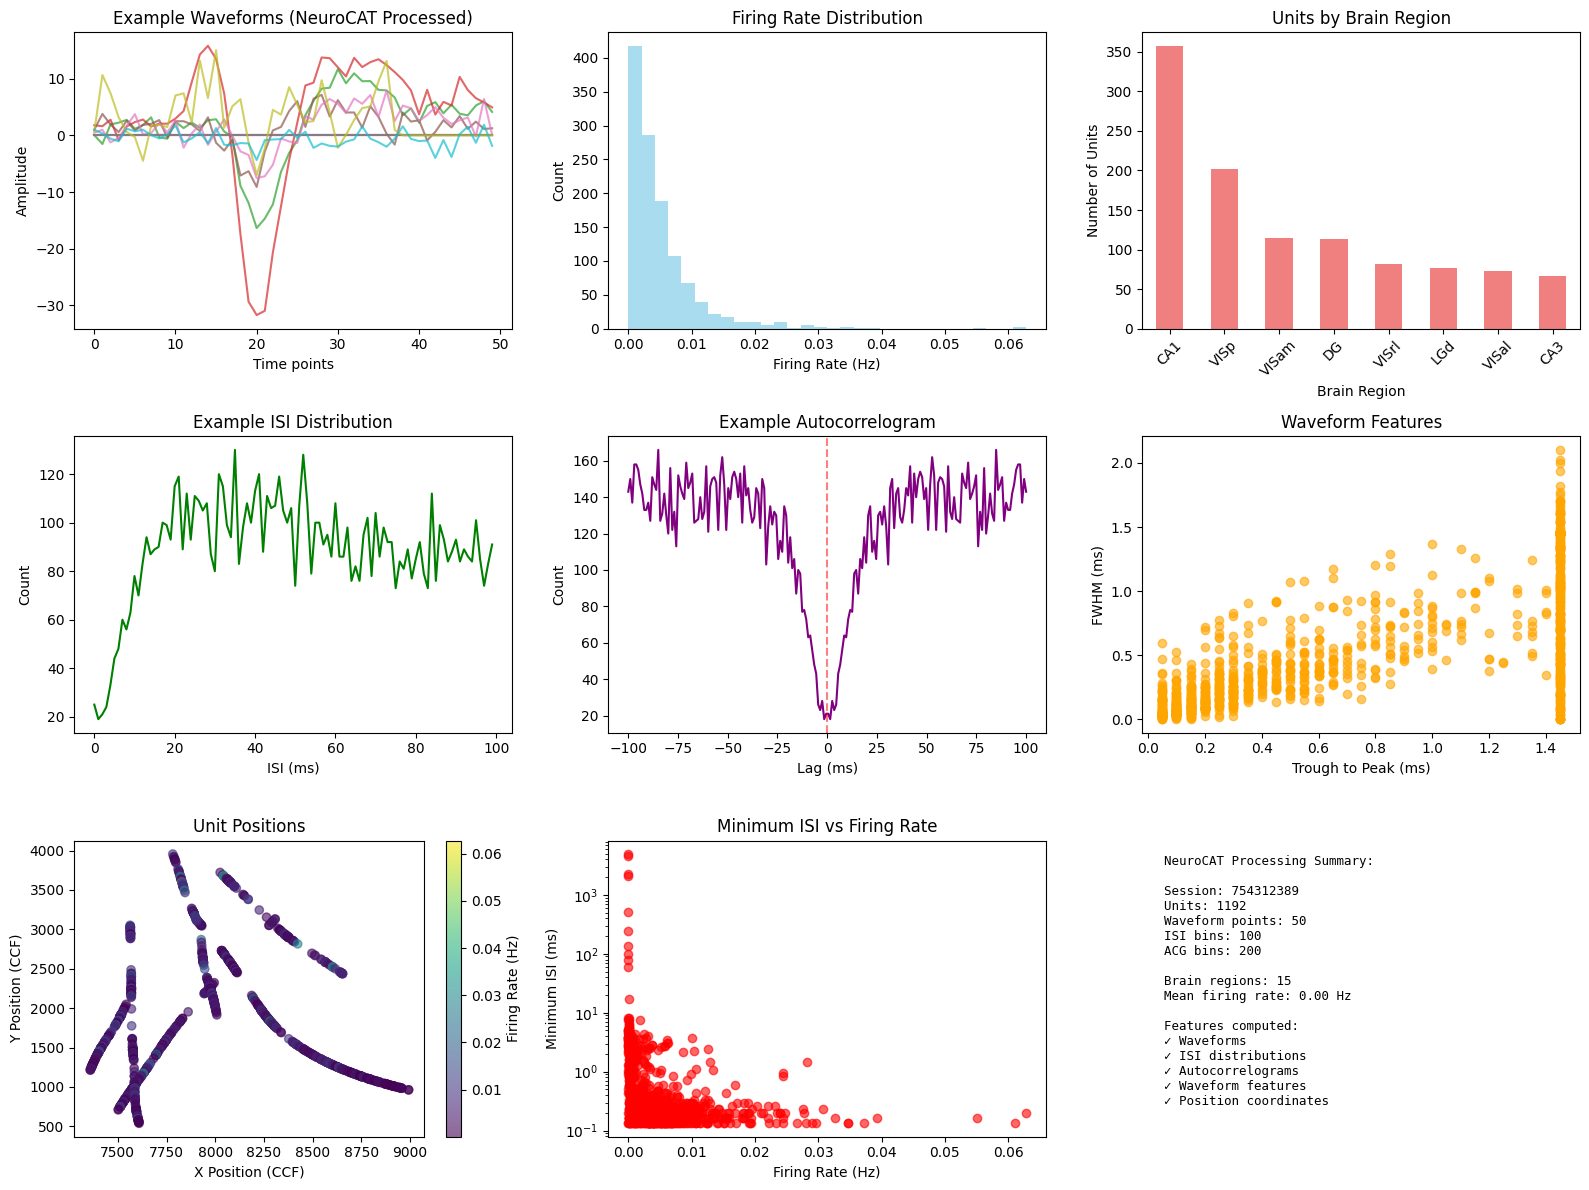


📊 Sample Metadata (NeuroCAT processed):


,unit_id,x,y,ecephys_structure_acronym,firing_rate,presence_ratio,isi_violations,amplitude_cutoff,session_type,specimen_id,age_in_days,sex,full_genotype,lpeak,rpeak,trough_to_peak,fwhm,fwhm_x,minimum_isi,session_id
0,951801738,8307.0,3130.0,APN,0.002962,0.99,0.128081,0.411609,brain_observatory_1.1,719828690,140.0,M,wt/wt,"(0, 0.0)","(49, 0.0)",1.45,1.450000,"[20.0, 49.0]",0.200000,754312389
1,951801727,8307.0,3130.0,APN,0.003368,0.99,0.259704,0.500000,brain_observatory_1.1,719828690,140.0,M,wt/wt,"(0, 0.0)","(49, 0.0)",1.45,1.450000,"[20.0, 49.0]",0.133333,754312389
2,951801788,8296.0,3103.0,APN,0.003885,0.99,0.174578,0.500000,brain_observatory_1.1,719828690,140.0,M,wt/wt,"(15, 2.8608450000000083)","(30, 11.708385000000007)",0.50,0.238851,"[17.91502423995288, 22.69204128751867]",0.200000,754312389
3,951801776,8296.0,3103.0,APN,0.005257,0.82,0.130871,0.098188,brain_observatory_1.1,719828690,140.0,M,wt/wt,"(14, 15.83634000000001)","(28, 13.77441)",0.40,0.234771,"[17.888929633986024, 22.584357260903925]",0.166667,754312389
4,951801763,8289.0,3086.0,POL,0.000079,0.60,30.468310,0.500000,brain_observatory_1.1,719828690,140.0,M,wt/wt,"(0, 0.0)","(49, 0.0)",1.45,1.450000,"[20.0, 49.0]",0.433334,754312389



🌊 Sample Waveforms:


,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,0.00000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.00000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.05889,-1.505790,1.950975,2.26083,2.755935,1.16181,1.848405,3.20385,-0.34086,-0.567255,...,2.275650,5.209815,5.885685,3.915405,5.423925,3.841305,3.557775,5.290350,6.045585,4.156035
3,1.80102,1.637805,2.783820,-0.84786,1.600560,2.36691,2.811510,1.58496,2.08611,2.072850,...,3.737955,8.059350,3.700320,5.932290,5.305950,10.350405,8.026980,6.583395,5.829525,4.962555
4,0.00000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000



✅ NeuroCAT processing completed successfully!
All data has been processed using the neurocurator.py functions
and exported in the standard NeuroCAT CSV format.


In [ ]:
# Visualize the processed data
if neurocurator is not None:
    plt.figure(figsize=(16, 12))
    
    # Subplot 1: Example waveforms
    plt.subplot(3, 3, 1)
    n_examples = min(10, len(neurocurator.waveforms))
    for i in range(n_examples):
        plt.plot(neurocurator.waveforms.iloc[i], alpha=0.7, label=f'Unit {i}')
    plt.title('Example Waveforms (Neurocurator Processed)')
    plt.xlabel('Time points')
    plt.ylabel('Amplitude')
    if n_examples <= 5:
        plt.legend()
    
    # Subplot 2: Firing rate distribution
    plt.subplot(3, 3, 2)
    firing_rates = neurocurator.metadata_obs['firing_rate'].dropna()
    plt.hist(firing_rates, bins=30, alpha=0.7, color='skyblue')
    plt.title('Firing Rate Distribution')
    plt.xlabel('Firing Rate (Hz)')
    plt.ylabel('Count')
    
    # Subplot 3: Brain region distribution
    plt.subplot(3, 3, 3)
    brain_regions = neurocurator.metadata_obs['ecephys_structure_acronym'].value_counts()
    if len(brain_regions) > 0:
        brain_regions.head(8).plot(kind='bar', color='lightcoral')
        plt.title('Units by Brain Region')
        plt.xlabel('Brain Region')
        plt.ylabel('Number of Units')
        plt.xticks(rotation=45)
    
    # Subplot 4: Example ISI distribution
    plt.subplot(3, 3, 4)
    if len(neurocurator.isi_distribution) > 0:
        example_isi = neurocurator.isi_distribution.iloc[0]
        plt.plot(example_isi, color='green')
        plt.title('Example ISI Distribution')
        plt.xlabel('ISI (ms)')
        plt.ylabel('Count')
    
    # Subplot 5: Example autocorrelogram
    plt.subplot(3, 3, 5)
    if len(neurocurator.acgs) > 0:
        example_acg = neurocurator.acgs.iloc[0]
        lags = np.linspace(-100, 100, len(example_acg))
        plt.plot(lags, example_acg, color='purple')
        plt.title('Example Autocorrelogram')
        plt.xlabel('Lag (ms)')
        plt.ylabel('Count')
        plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
    
    # Subplot 6: Waveform features scatter
    plt.subplot(3, 3, 6)
    if 'trough_to_peak' in neurocurator.metadata_obs.columns and 'fwhm' in neurocurator.metadata_obs.columns:
        ttp = neurocurator.metadata_obs['trough_to_peak']
        fwhm = neurocurator.metadata_obs['fwhm']
        plt.scatter(ttp, fwhm, alpha=0.6, color='orange')
        plt.xlabel('Trough to Peak (ms)')
        plt.ylabel('FWHM (ms)')
        plt.title('Waveform Features')
    
    # Subplot 7: Position plot (if available)
    plt.subplot(3, 3, 7)
    if 'x' in neurocurator.metadata_obs.columns and 'y' in neurocurator.metadata_obs.columns:
        x_pos = neurocurator.metadata_obs['x']
        y_pos = neurocurator.metadata_obs['y']
        plt.scatter(x_pos, y_pos, alpha=0.6, c=firing_rates if len(firing_rates) == len(x_pos) else 'blue')
        plt.xlabel('X Position (CCF)')
        plt.ylabel('Y Position (CCF)')
        plt.title('Unit Positions')
        if len(firing_rates) == len(x_pos):
            plt.colorbar(label='Firing Rate (Hz)')
    
    # Subplot 8: Minimum ISI vs Firing Rate
    plt.subplot(3, 3, 8)
    if 'minimum_isi' in neurocurator.metadata_obs.columns:
        min_isi = neurocurator.metadata_obs['minimum_isi']
        plt.scatter(firing_rates[:len(min_isi)], min_isi, alpha=0.6, color='red')
        plt.xlabel('Firing Rate (Hz)')
        plt.ylabel('Minimum ISI (ms)')
        plt.title('Minimum ISI vs Firing Rate')
        plt.yscale('log')
    
    # Subplot 9: Data summary text
    plt.subplot(3, 3, 9)
    plt.axis('off')
    summary_text = (
        f"Neurocurator Processing Summary:\n\n"
        f"Session: {session_id}\n"
        f"Units: {len(neurocurator.metadata_obs)}\n"
        f"Waveform points: {neurocurator.waveforms.shape[1]}\n"
        f"ISI bins: {neurocurator.isi_distribution.shape[1]}\n"
        f"ACG bins: {neurocurator.acgs.shape[1]}\n\n"
        f"Brain regions: {len(brain_regions)}\n"
        f"Mean firing rate: {firing_rates.mean():.2f} Hz\n\n"
        f"Features computed:\n"
        f" Waveforms\n"
        f" ISI distributions\n"
        f" Autocorrelograms\n"
        f" Waveform features\n"
        f" Position coordinates"
    )
    plt.text(0.05, 0.95, summary_text, transform=plt.gca().transAxes, 
             verticalalignment='top', fontfamily='monospace', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Display sample data
    print("\n📊 Sample Metadata (Neurocurator processed):")
    display(neurocurator.metadata_obs.head())
    
    print("\n🌊 Sample Waveforms:")
    display(neurocurator.waveforms.head())
    
    print(f"\n Neurocurator processing completed successfully!")
    print(f"All data has been processed using the neurocurator.py functions")
    print(f"and exported in the standard Neurocurator CSV format.")
    
else:
    print("Cannot visualize data - neurocurator processing failed.")